In [1]:
# basics libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

# Libraries for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Units libraries
import metpy.calc as mpcalc
from metpy.units import units

# Time libraries
import matplotlib.dates as mdates

# For metocean statistics
from metocean_stats import plots, tables

# Plots libraries
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.colors as colors
from matplotlib.lines import Line2D

Dataset used for latitude, longitude definition

In [2]:
ds_0 = xr.open_dataset("C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc", engine="h5netcdf")
ds_0

<xarray.Dataset> Size: 16MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    diff       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

Bathymetry dataset

In [3]:
ds_bathy = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Grid//MED36_bathy_meter.nc", engine="scipy")
ds_bathy

<xarray.Dataset> Size: 16MB
Dimensions:     (Y: 787, X: 1651)
Coordinates:
  * X           (X) int32 7kB 1 2 3 4 5 6 7 ... 1646 1647 1648 1649 1650 1651
  * Y           (Y) int32 3kB 1 2 3 4 5 6 7 8 ... 781 782 783 784 785 786 787
Data variables:
    nav_lon     (Y, X) float32 5MB ...
    nav_lat     (Y, X) float32 5MB ...
    Bathymetry  (Y, X) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

In [4]:
ds_bathy = ds_bathy.rename({"Y": "latitude", "X": "longitude"})
ds_bathy

<xarray.Dataset> Size: 16MB
Dimensions:     (latitude: 787, longitude: 1651)
Coordinates:
  * longitude   (longitude) int32 7kB 1 2 3 4 5 6 ... 1647 1648 1649 1650 1651
  * latitude    (latitude) int32 3kB 1 2 3 4 5 6 7 ... 782 783 784 785 786 787
Data variables:
    nav_lon     (latitude, longitude) float32 5MB ...
    nav_lat     (latitude, longitude) float32 5MB ...
    Bathymetry  (latitude, longitude) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

Define datasets

In [5]:
# No currents 
ds_1 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Snapshots_analysis//standard_no_cur_snapshots.nc", engine="h5netcdf")
ds_1

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 16B 2020-01-29T01:00:00 2020-01-31T06:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    dir      (time, latitude, longitude) float32 10MB ...
    hs       (time, latitude, longitude) float32 10MB ...
    t01      (time, latitude, longitude) float32 10MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_no_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Wed Jan 14 16:47:18 2026: ncks -C -O -x...
    history_of_appended_files:        Wed Jan 14 16:41:48 2026: Appended file...
    NCO:                              "4.5.2"

In [6]:
# Difference between two runs
ds_2 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Snapshots_analysis//standard_diff_snapshots.nc", engine="h5netcdf")
ds_2

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 16B 2020-01-29T01:00:00 2020-01-31T06:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    hs       (time, latitude, longitude) float32 10MB ...
    dir      (time, latitude, longitude) float32 10MB ...
    t01      (time, latitude, longitude) float32 10MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents_new_stan202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Wed Jan 14 16:48:21 2026: ncks -A addit...
    history_of_appended_files:        Wed Jan 14 16:48:21 2026: Appended file...
    NCO:                              "4.5.2"

In [7]:
# Forcings
ds_3 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Snapshots_analysis//forcings_snapshots.nc", engine="h5netcdf")
ds_3

<xarray.Dataset> Size: 42MB
Dimensions:  (time: 2, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 16B 2020-01-29T01:00:00 2020-01-31T06:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    ucur     (time, latitude, longitude) float32 10MB ...
    vcur     (time, latitude, longitude) float32 10MB ...
    uwnd     (time, latitude, longitude) float32 10MB ...
    vwnd     (time, latitude, longitude) float32 10MB ...
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    history:                          Wed Jan 14 15:37:03 2026: cdo -select,n...
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [8]:
# With currents
ds_4 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Analysis//Pure analysis//Snapshots_analysis//standard_with_cur_snapshots.nc", engine="h5netcdf")
ds_4

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 16B 2020-01-29T01:00:00 2020-01-31T06:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    hs       (time, latitude, longitude) float32 10MB ...
    dir      (time, latitude, longitude) float32 10MB ...
    t01      (time, latitude, longitude) float32 10MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents_new_stan202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Wed Jan 14 16:47:57 2026: ncks -A addit...
    history_of_appended_files:        Wed Jan 14 16:47:57 2026: Appended file...
    NCO:                              "4.5.2"

Assing coordinates to the data

In [9]:
ds_1 = ds_1.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_2 = ds_2.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_3 = ds_3.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_4 = ds_4.assign_coords(latitude=ds_0.latitude, longitude=ds_0.longitude)
ds_bathy = ds_bathy.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_bathy

<xarray.Dataset> Size: 26MB
Dimensions:     (latitude: 787, longitude: 1651)
Coordinates:
    latitude    (latitude, longitude) float32 5MB ...
    longitude   (latitude, longitude) float32 5MB ...
Data variables:
    nav_lon     (latitude, longitude) float32 5MB ...
    nav_lat     (latitude, longitude) float32 5MB ...
    Bathymetry  (latitude, longitude) float32 5MB ...
Attributes:
    Conventions:    CF-1.5
    Grid:           ARAKAWA-C
    Created_by:     SIREN create_bathy
    Creation_date:  2017-01-19 13:00:32
    periodicity:    0.0
    history:        Tue Mar  7 14:42:16 2017: ncrename -d x,X -d y,Y test.nc....

Select multiple regions of interest

In [10]:
regions = {
    "Asia_Minor": [28, 33, 35, 37],
    "Alboran_Sea & Algeria and Tunisia coasts": [-6, 9.8, 35, 38.8],
    "Strait_of_Sicily till S. Levantine": [15, 20, 32.5, 37.5],
    "S. Levantine" : [20,30,31,33.8]
}

In [11]:
def select_multiple_regions(ds, regions):
    lon = ds.longitude
    lat = ds.latitude

    mask = xr.zeros_like(lon, dtype=bool)

    for lon_min, lon_max, lat_min, lat_max in regions.values():
        mask |= (
            (lon >= lon_min) & (lon <= lon_max) &
            (lat >= lat_min) & (lat <= lat_max)
        )

    return ds.where(mask, drop=True)

In [12]:
ds_0_sel = select_multiple_regions(ds_0, regions)
ds_1_sel = select_multiple_regions(ds_1, regions)
ds_2_sel = select_multiple_regions(ds_2, regions)
ds_3_sel = select_multiple_regions(ds_3, regions)
ds_4_sel = select_multiple_regions(ds_4, regions)
ds_bathy_sel = select_multiple_regions(ds_bathy, regions)
ds_0_sel

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 1, bnds: 2, latitude: 358, longitude: 1221)
Coordinates:
    latitude   (latitude, longitude) float32 2MB 31.15 31.15 ... 38.06 38.06
    longitude  (latitude, longitude) float32 2MB -6.097 -6.069 ... 33.06 33.09
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds, latitude, longitude) datetime64[ns] 7MB NaT ... NaT
    diff       (time, latitude, longitude) float32 2MB nan nan nan ... nan nan
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

Drawing multiple regions of interest

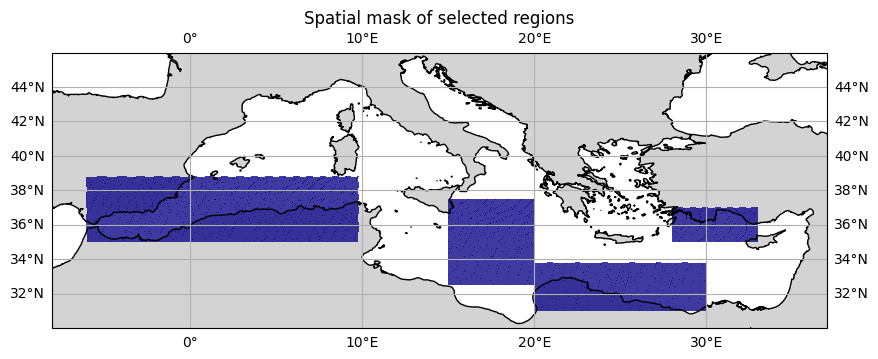

In [13]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.gridlines(draw_labels=True)

lon = ds_0.longitude
lat = ds_0.latitude

region_mask = xr.zeros_like(lon, dtype=bool)

for bounds in regions.values():
    lon_min, lon_max, lat_min, lat_max = bounds

    region_mask |= (
        (lon >= lon_min) & (lon <= lon_max) &
        (lat >= lat_min) & (lat <= lat_max)
    )
mask_plot = region_mask.where(region_mask)

ax.pcolormesh(
    ds_0.longitude,
    ds_0.latitude,
    mask_plot,
    transform=ccrs.PlateCarree(),
    cmap="plasma",
    alpha=0.8
)

ax.set_extent([-8, 37, 30, 46], crs=ccrs.PlateCarree())
ax.set_title("Spatial mask of selected regions")

plt.show()


Setting variables

In [14]:
# Setting variables from dataset

# Standard wave parameters : Hs, t01, t02, t0m1, fp, dir, spr, c_group, stepness, wavelength

# lat-lon
lon = ds_0_sel["longitude"]
lat = ds_0_sel["latitude"]

# diff
diff_hs = ds_2_sel["hs"][:,:,:]
diff_t01 = ds_2_sel["t01"][:,:,:]
#diff_spread = ds_2_sel["spr"][:,:,:]
diff_wave_dir = ds_2_sel["dir"][:,:,:]
#diff_fp = ds_2_sel["fp"][:,:,:]

# forcings
ucur = ds_3_sel["ucur"][:,:,:]
vcur = ds_3_sel["vcur"][:,:,:]
uwnd = ds_3_sel["uwnd"][:,:,:]
vwnd = ds_3_sel["vwnd"][:,:,:]

# no currents parameters
hs_no_cur = ds_1_sel["hs"][:,:,:]
t01_no_cur = ds_1_sel["t01"][:,:,:]
#spread_no_cur = ds_1_sel["spr"][:,:,:]
wave_dir_no_cur = ds_1_sel["dir"][:,:,:]
#fp_no_cur = ds_1_sel["fp"][:,:,:]

# with currents parameters
wave_dir_with_cur = ds_4_sel["dir"][:,:,:]
t01_with_cur = ds_4_sel["t01"][:,:,:]
hs_with_cur = ds_4_sel["hs"][:,:,:]

# Bathymetry
Bathymetry = ds_bathy_sel["Bathymetry"][:,:]

Setting values & units of variables

In [15]:
# lat-lon
lon2d = lon.values
lat2d = lat.values

# diff
diff_hs2d = diff_hs.values * units("m")
diff_t012d = diff_t01.values * units("s")
#diff_spread = diff_spread.values
diff_wave_dir2d = diff_wave_dir.values
#diff_fp2d = diff_fp.values * units("1/s")


# forcings
ucur2d = ucur.values * units("m/s") 
vcur2d = vcur.values * units("m/s")
uwnd2d = uwnd.values * units("m/s")
vwnd2d = vwnd.values * units("m/s")

# no currents parameters
hs_no_cur = hs_no_cur.values * units("m")
t01_no_cur = t01_no_cur.values * units("s")
#spread_no_cur = spread_no_cur.values
wave_dir_no_cur = wave_dir_no_cur.values
#fp_no_cur = fp_no_cur.values * units("1/s")

# with currents parameters
wave_dir_with_cur = wave_dir_with_cur.values
t01_with_cur = t01_with_cur.values * units("s")
hs_with_cur = hs_with_cur.values * units("m")

# Bathymetry
Bathymetry = Bathymetry.values * units("m")

Additional parameters

In [16]:
wnd_speed = np.sqrt(uwnd2d**2 + vwnd2d**2) 
cur_speed = np.sqrt(ucur2d**2 + vcur2d**2)
g = 9.81 * units("m/s**2")
c_phase_with_cur=(g*t01_with_cur)/(2*np.pi)
c_group_with_cur=(g*t01_with_cur)/(4*np.pi)
c_phase_no_cur=(g*t01_no_cur)/(2*np.pi)
c_group_no_cur=(g*t01_no_cur)/(4*np.pi)
wavelength_with_cur=(g*(t01_with_cur**2))/(2*np.pi)
wavelength_no_cur=(g*(t01_no_cur**2))/(2*np.pi)
stepness_with_cur = hs_with_cur/wavelength_with_cur
stepness_no_cur = hs_no_cur/wavelength_no_cur
wave_age_with_cur = c_phase_with_cur/wnd_speed
wave_age_no_cur = c_phase_no_cur/wnd_speed

c:\Users\kosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\pint\facets\plain\quantity.py:1029: RuntimeWarning: divide by zero encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


In [17]:
diff_stepness2d = stepness_with_cur - stepness_no_cur
diff_wavelength = wavelength_with_cur - wavelength_no_cur
diff_c_group2d = c_group_with_cur - c_group_no_cur

Transforming wind and currents direction with respect to the meteorological convection

In [18]:
wnd_dir = np.degrees(np.arctan2(vwnd, uwnd))
wnd_dir = (270 - wnd_dir) % 360
cur_dir = np.degrees(np.arctan2(vcur, ucur))
cur_dir = (270 - cur_dir) % 360

Computation of wave components from wave direction

In [19]:
# WaveWatch direction: degrees, FROM, clockwise from North
D = wave_dir_no_cur  # shape (time, lat, lon)

# FROM -> TO
D_to = (D + 180) % 360

# Meteorological -> mathematical (radians)
theta = np.deg2rad(90 - D_to)

# Unit direction vectors
u_group_no_cur = c_group_no_cur*np.cos(theta)
v_group_no_cur = c_group_no_cur*np.sin(theta)

Computation of relative angles

In [20]:
angle_bet_cur_wave =  cur_dir - wave_dir_no_cur
angle_bet_cur_wnd = cur_dir - wnd_dir

Angle between currents and wind

In [21]:
rel_angle_cur_wnd = xr.where((wnd_dir < 180) & (angle_bet_cur_wnd <= 180), angle_bet_cur_wnd, xr.where(
    (wnd_dir < 180) & (angle_bet_cur_wnd > 180), angle_bet_cur_wnd - 360, xr.where(
        (wnd_dir > 180) & (angle_bet_cur_wnd >= -180), angle_bet_cur_wnd, xr.where(
            (wnd_dir > 180) & (angle_bet_cur_wnd < -180), 360 + angle_bet_cur_wnd, angle_bet_cur_wnd)
    ) 
))
np.nanmax(rel_angle_cur_wnd), np.nanmin(rel_angle_cur_wnd),np.shape(rel_angle_cur_wnd)

(np.float32(179.99754), np.float32(-179.99976), (2, 358, 1221))

Angle between currents and waves

In [22]:
rel_angle_wave = xr.where((wave_dir_no_cur < 180) & (angle_bet_cur_wave <= 180), angle_bet_cur_wave, xr.where(
    (wave_dir_no_cur < 180) & (angle_bet_cur_wave > 180), angle_bet_cur_wave - 360, xr.where(
        (wave_dir_no_cur > 180) & (angle_bet_cur_wave >= -180), angle_bet_cur_wave, xr.where(
            (wave_dir_no_cur > 180) & (angle_bet_cur_wave < -180), 360 + angle_bet_cur_wave, angle_bet_cur_wave)
    ) 
))
np.nanmax(rel_angle_wave), np.nanmin(rel_angle_wave),np.shape(rel_angle_wave)

(np.float32(179.99985), np.float32(-179.99774), (2, 358, 1221))

Compute gradients, divergence and vorticity

In [23]:
# Compute grid spacing in meters
dx_g, dy_g = mpcalc.lat_lon_grid_deltas(lon2d, lat2d)
dx_g, dy_g

(<Quantity([[2644.93759837 2645.03239137 2644.94472231 ... 2649.24551953
   2649.24258463 2649.98459192]
  [2644.27912367 2644.37194018 2644.42134661 ... 2648.63272341
   2649.35581954 2648.64081699]
  [2643.71017119 2643.75861691 2643.71534753 ... 2647.66093219
   2648.02155648 2648.02815949]
  ...
  [2409.57766875 2409.70847008 2409.61249765 ... 2428.9744113
   2429.05439162 2429.06642474]
  [2408.97070761 2408.96738723 2408.88262756 ... 2428.38241022
   2428.44527361 2428.49146947]
  [2408.19935716 2408.31934233 2408.27570443 ... 2427.84126086
   2426.86938805 2427.89964721]], 'meter')>,
 <Quantity([[2627.5779955  2627.36591037 2627.57799562 ... 2466.21929061
   2466.22476639 2466.43137272]
  [2626.51755594 2626.51797121 2626.30609492 ... 2465.37640786
   2464.31052516 2464.0984438 ]
  [2625.24607507 2625.45816024 2625.45753168 ... 2464.10670537
   2464.10388756 2464.10388783]
  ...
  [2374.7624089  2374.76435372 2374.76630138 ... 1991.81649713
   1990.54502619 1989.69739223]
  [237

In [24]:
t,x,y = np.shape(diff_hs2d)[0], np.shape(diff_hs2d)[1], np.shape(diff_hs2d)[2]
t,x,y

(2, 358, 1221)

In [25]:
"""grad_diff_hs = np.zeros((t,2,x,y))
grad_hs_no_cur = np.zeros((t,2,x,y))
grad_u = np.zeros((t,2,x,y))
grad_v = np.zeros((t,2,x,y))
grad_U = np.zeros((t,2,x,y))
div_hs_no_cur = np.zeros((t,x,y))
div_diff_hs = np.zeros((t,x,y))"""
div = np.zeros((t,x,y))
vor = np.zeros((t,x,y))
normal_vor = np.zeros((t,x,y))
omega = 7.2921*(10**(-5))
f = 2*omega*np.sin(np.deg2rad(lat2d))

for j in range(0,2):
    """gr_diff_hs = mpcalc.gradient(diff_hs2d[j], deltas=(dy_g, dx_g))
    gr_hs_no_cur = mpcalc.gradient(hs_no_cur[j], deltas=(dy_g, dx_g))
    gr_u = mpcalc.gradient(ucur2d[j], deltas=(dy_g, dx_g))
    gr_v = mpcalc.gradient(vcur2d[j], deltas=(dy_g, dx_g))
    gr_U = mpcalc.gradient(cur_speed[j], deltas=(dy_g, dx_g))
    d_hs_no_cur = mpcalc.divergence(hs_no_cur[j],hs_no_cur[j],dx=dx_g,dy=dy_g)
    d_diff_hs = mpcalc.divergence(diff_hs2d[j],diff_hs2d[j],dx=dx_g,dy=dy_g)"""
    d = mpcalc.divergence(ucur2d[j],vcur2d[j],dx=dx_g,dy=dy_g)
    v = mpcalc.vorticity(ucur2d[j],vcur2d[j],dx=dx_g,dy=dy_g)
    normal_v = (v)/(f)

    """grad_diff_hs[j] = gr_diff_hs
    grad_hs_no_cur[j] = gr_hs_no_cur
    grad_u[j] = gr_u
    grad_v[j] = gr_v
    grad_U[j] = gr_U
    div_hs_no_cur[j] = d_hs_no_cur
    div_diff_hs[j] = d_diff_hs"""
    div[j] = d
    vor[j] = v
    normal_vor[j] = normal_v

np.shape(div), np.shape(normal_vor), np.shape(vor)

((2, 358, 1221), (2, 358, 1221), (2, 358, 1221))

Masking nan values

In [26]:
div_masked = np.ma.masked_invalid(div)
normal_vor_masked = np.ma.masked_invalid(normal_vor)
vor_masked = np.ma.masked_invalid(vor)

Style plots fuctions

In [27]:
import numpy as np
from scipy.stats import skew, kurtosis, normaltest

def adaptive_percentile_range(data):
    """
    Compute an adaptive percentile range for plotting, 
    depending on the data distribution.
    
    Returns (lower_bound, upper_bound, coverage_percent).
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)]  # remove NaNs and infs

    # Basic distribution metrics
    s = skew(data)
    k = kurtosis(data)
    stat, pval = normaltest(data)  # normality test (null: normal)

    # Start with default 95% range
    coverage = 95.0
    
    # Adjust for heavy tails or skewed data
    if pval < 0.05:  # not normal
        if abs(s) > 1 or k > 3:       # strongly skewed or heavy tails
            coverage = 90.0
        elif abs(s) > 0.5 or k > 1:   # moderately skewed
            coverage = 93.0
    else:
        coverage = 98.0  # almost normal, show more of the data

    lower = (100 - coverage) / 2
    upper = 100 - lower
    bounds = np.percentile(data, [lower, upper])

    return bounds, coverage


Heatmap analysis

Masking nan values

In [28]:
mask_1 = ~np.isnan(rel_angle_cur_wnd) & ~np.isnan(rel_angle_wave) & ~np.isnan(cur_speed) & ~np.isnan(diff_hs2d) & ~np.isnan(diff_wave_dir2d) & ~np.isnan(vor_masked)

rel_angle_cur_wnd = xr.where(mask_1, rel_angle_cur_wnd, np.nan)
rel_angle_wave = xr.where(mask_1, rel_angle_wave, np.nan)
cur_speed = np.where(mask_1, cur_speed, np.nan)
diff_hs2d = xr.where(mask_1, diff_hs2d, np.nan)
diff_wave_dir2d = xr.where(mask_1, diff_wave_dir2d, np.nan)
vorticity = np.where(mask_1, vor_masked, np.nan)

Reshaping variables into 1-D format, in order to be used in the binned plots below

In [29]:
rel_angle_cur_wnd  = rel_angle_cur_wnd.values.reshape(-1)
rel_angle_wave  = rel_angle_wave.values.reshape(-1)
cur_speed  = cur_speed.reshape(-1)  
diff_hs2d = diff_hs2d.values.reshape(-1)
diff_wave_dir2d = diff_wave_dir2d.values.reshape(-1)
vorticity = vorticity.reshape(-1)

Define bins and centers

In [30]:
n_angle_bins = 24 # 10° bins if range is -180–180
n_speed_bins = 10  # depends on range of your current speeds
n_vorticity_bins = 10   

bounds_rel_angle_cur_wnd,_ = adaptive_percentile_range(rel_angle_cur_wnd)
min_rel_angle_cur_wnd, max_rel_angle_cur_wnd = bounds_rel_angle_cur_wnd
rel_angle_cur_wnd_bins = np.round(np.linspace(min_rel_angle_cur_wnd, max_rel_angle_cur_wnd, n_angle_bins + 1))

bounds_rel_angle_cur_waves,_ = adaptive_percentile_range(rel_angle_wave)
min_rel_angle_cur_waves, max_rel_angle_cur_waves = bounds_rel_angle_cur_waves
rel_angle_cur_waves_bins = np.round(np.linspace(min_rel_angle_cur_waves, max_rel_angle_cur_waves, n_angle_bins + 1))

bounds_cur_speed,_ = adaptive_percentile_range(cur_speed)
min_cur_speed, max_cur_speed = bounds_cur_speed
cur_speed_bins = np.round(np.linspace(min_cur_speed, max_cur_speed, n_speed_bins + 1), 2)

bounds_vorticity,_ = adaptive_percentile_range(vorticity)
min_vorticity, max_vorticity = bounds_vorticity
abs_max = max(abs(min_vorticity), abs(max_vorticity))
vorticity_bins = np.round(np.linspace(-abs_max, abs_max, n_vorticity_bins + 1), 7)

In [31]:
def circular_mean_deg(angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.arctan2(
        np.nanmean(np.sin(angle_rad)),
        np.nanmean(np.cos(angle_rad))
    ))

Heatmaps

In [32]:
mask_n_bins_1 = [n_angle_bins, n_angle_bins, n_vorticity_bins]

mask_n_bins_2 = [n_speed_bins, n_speed_bins, n_speed_bins]

diff_swh_0 = np.full((n_speed_bins, mask_n_bins_1[0]), np.nan) 
diff_swh_1 = np.full((n_speed_bins, mask_n_bins_1[1]), np.nan) 
diff_dir = np.full((n_speed_bins, mask_n_bins_1[2]), np.nan) 
diff_parameters = [diff_swh_0, diff_swh_1, diff_dir]

mask_cond_1 = [rel_angle_cur_wnd, rel_angle_wave, vorticity]

mask_bins_1 = [rel_angle_cur_wnd_bins, rel_angle_cur_waves_bins, vorticity_bins]

mask_cond_2 = [cur_speed, cur_speed, cur_speed]

mask_bins_2 = [cur_speed_bins, cur_speed_bins, cur_speed_bins]

for k in range(0,3):
    for i in range(mask_n_bins_1[k]):
        for j in range(mask_n_bins_2[k]):
            mask_bin = (
                (np.asarray(mask_cond_1[k]) >= mask_bins_1[k][i]) & 
                (np.asarray(mask_cond_1[k]) < mask_bins_1[k][i + 1]) 
                &
                (np.asarray(mask_cond_2[k]) >= mask_bins_2[k][j]) & 
                (np.asarray(mask_cond_2[k]) < mask_bins_2[k][j + 1])
            )
            if np.any(mask_bin):
                if k != 2:
                    diff_parameters[k][j,i] = np.round(np.nanmean(diff_hs2d[mask_bin]),2) 
                else:
                    diff_parameters[k][j,i] = circular_mean_deg(diff_wave_dir2d[mask_bin])

Text(0.5, 1.0, 'Difference of wave direction')

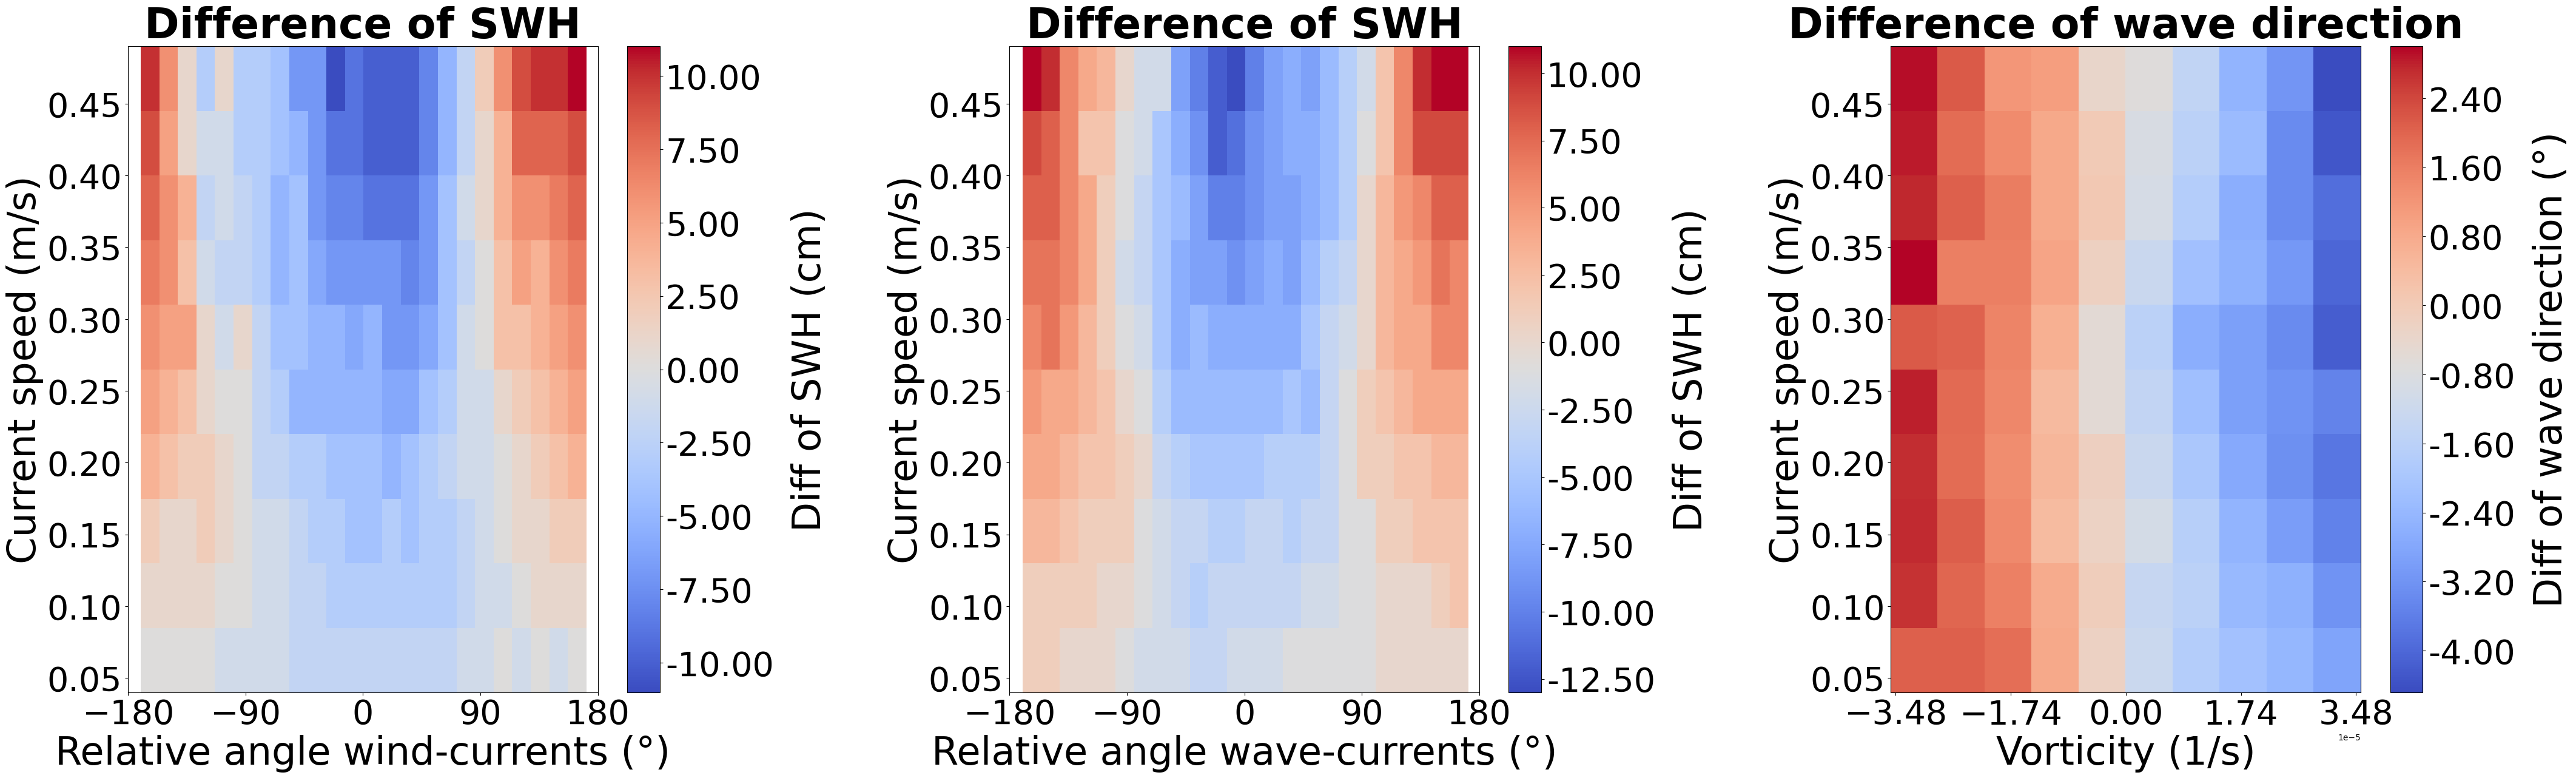

In [33]:
import os
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator

bounds, _ = adaptive_percentile_range(diff_parameters[0])
vmin, vmax = bounds

#fig, ax = plt.subplots(figsize=(10, 5))

fig = plt.figure(figsize=(50, 47))
#fig.suptitle(f'Binned wave parameters', x=0.5,y=0.92, 
#                 ha='center',fontsize = 24)

ax1 = fig.add_subplot(3, 3, 1)
ax2 = fig.add_subplot(3, 3, 2)
ax3 = fig.add_subplot(3, 3, 3)
plt.subplots_adjust(wspace=0.5)  # increase horizontal spacing

#norm = colors.Normalize(vmin=vmin, vmax=vmax)
im = ax1.imshow(
    100*diff_parameters[0], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[0][0], mask_bins_1[0][-1], mask_bins_2[0][0], mask_bins_2[0][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
#plt.colorbar(im, label='Diff of SWH (cm)')
cbar = plt.colorbar(im)
cbar.set_label('Diff of SWH (cm)', size=46, labelpad=20)
cbar.ax.tick_params(labelsize=40)
#style_axis(ax1, title="Control experiment SWH", cbar=cbar, cbar_tick_fontsize=44)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

ticks = [-180, -90, 0, 90, 180]
ax1.set_xticks(ticks)
ax1.tick_params(axis='x', labelsize=40)
ax1.tick_params(axis='y', labelsize=40)
ax1.set_xlabel('Relative angle wind-currents (°)',fontsize=46)
ax1.set_ylabel('Current speed (m/s)', fontsize=46)
ax1.set_title('Difference of SWH', fontsize=50, weight='bold')

bounds, _ = adaptive_percentile_range(diff_parameters[1])
vmin, vmax = bounds

im = ax2.imshow(
    100*diff_parameters[1], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=100*[mask_bins_1[1][0], mask_bins_1[1][-1], mask_bins_2[1][0], mask_bins_2[1][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
#plt.colorbar(im, label='Diff of SWH (cm)')
cbar = plt.colorbar(im)
cbar.set_label('Diff of SWH (cm)', size=46, labelpad=20)
cbar.ax.tick_params(labelsize=40)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

ticks = [-180, -90, 0, 90, 180]
#ax1.set_xticks(mask_bins_1[0][::3])
ax2.set_xticks(ticks)
ax2.tick_params(axis='x', labelsize=40)
ax2.tick_params(axis='y', labelsize=40)
ax2.set_xlabel('Relative angle wave-currents (°)',fontsize=46)
ax2.set_ylabel('Current speed (m/s)',fontsize=46)
ax2.set_title('Difference of SWH',fontsize=50, weight='bold')

im = ax3.imshow(
    diff_parameters[2], 
    origin='lower',               # so lower left corresponds to smallest bins
    aspect='auto',                # to avoid distortion
    extent=[mask_bins_1[2][0], mask_bins_1[2][-1], mask_bins_2[2][0], mask_bins_2[2][-1]], 
    cmap='coolwarm',                # choose a color map you like (e.g. 'plasma', 'coolwarm', 'turbo')
    #norm=norm
)
#plt.colorbar(im, label='Diff of wave direction (°)')
cbar = plt.colorbar(im)
cbar.set_label('Diff of wave direction (°)', size=46, labelpad=20)
cbar.ax.tick_params(labelsize=40)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

bounds, _ = adaptive_percentile_range(mask_bins_1[2])
min,max=bounds
ticks = [min,0.5*min,0*max,0.5*max,max]
ax3.set_xticks(ticks)
#ax3.set_xticks(mask_bins_1[2][::2])
ax3.tick_params(axis='x', labelsize=40)
ax3.tick_params(axis='y', labelsize=40)
ax3.set_xlabel('Vorticity (1/s)',fontsize=46)
ax3.set_ylabel('Current speed (m/s)',fontsize=46)
ax3.set_title('Difference of wave direction',fontsize=50, weight='bold')